In [1]:
import pandas as pd

df = pd.read_csv('Crop_recommendation.csv')
df.head()

FileNotFoundError: [Errno 2] No such file or directory: 'Crop_recommendation.csv'

In [2]:
from google.colab import files
uploaded = files.upload()

Saving Crop_recommendation.csv to Crop_recommendation.csv


In [3]:
df.head()

NameError: name 'df' is not defined

In [4]:
df.columns = df.columns.str.strip()
print(df.columns)

NameError: name 'df' is not defined

In [5]:
df.groupby('State')['Production'].sum().sort_values(ascending=False).head()

NameError: name 'df' is not defined

In [6]:
df.groupby('State_Name')['Production'].sum().sort_values(ascending=False).head()

NameError: name 'df' is not defined

In [7]:
df.groupby('State')['Production '].sum().sort_values(ascending=False).head()

NameError: name 'df' is not defined

In [8]:
import os
os.listdir()

['.config', 'drive', 'Crop_recommendation.csv', 'sample_data']

In [9]:
import pandas as pd

df = pd.read_csv('Crop_recommendation.csv')
print(df.columns)

Index(['N', 'P', 'K', 'temperature', 'humidity', 'ph', 'rainfall', 'label'], dtype='object')


In [10]:
df['label'].value_counts()


,count
label,
rice,100
maize,100
chickpea,100
kidneybeans,100
pigeonpeas,100
mothbeans,100
mungbean,100
blackgram,100
lentil,100


In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2200 entries, 0 to 2199
Data columns (total 8 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   N            2200 non-null   int64  
 1   P            2200 non-null   int64  
 2   K            2200 non-null   int64  
 3   temperature  2200 non-null   float64
 4   humidity     2200 non-null   float64
 5   ph           2200 non-null   float64
 6   rainfall     2200 non-null   float64
 7   label        2200 non-null   object 
dtypes: float64(4), int64(3), object(1)
memory usage: 137.6+ KB


In [12]:
df.describe()

,N,P,K,temperature,humidity,ph,rainfall
count,2200.000000,2200.000000,2200.000000,2200.000000,2200.000000,2200.000000,2200.000000
mean,50.551818,53.362727,48.149091,25.616244,71.481779,6.469480,103.463655
std,36.917334,32.985883,50.647931,5.063749,22.263812,0.773938,54.958389
min,0.000000,5.000000,5.000000,8.825675,14.258040,3.504752,20.211267
25%,21.000000,28.000000,20.000000,22.769375,60.261953,5.971693,64.551686
50%,37.000000,51.000000,32.000000,25.598693,80.473146,6.425045,94.867624
75%,84.250000,68.000000,49.000000,28.561654,89.948771,6.923643,124.267508
max,140.000000,145.000000,205.000000,43.675493,99.981876,9.935091,298.560117


In [13]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier

X = df.drop('label', axis=1)
y = df['label']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

model = RandomForestClassifier()
model.fit(X_train, y_train)

print("Accuracy:", model.score(X_test, y_test))

Accuracy: 0.9977272727272727


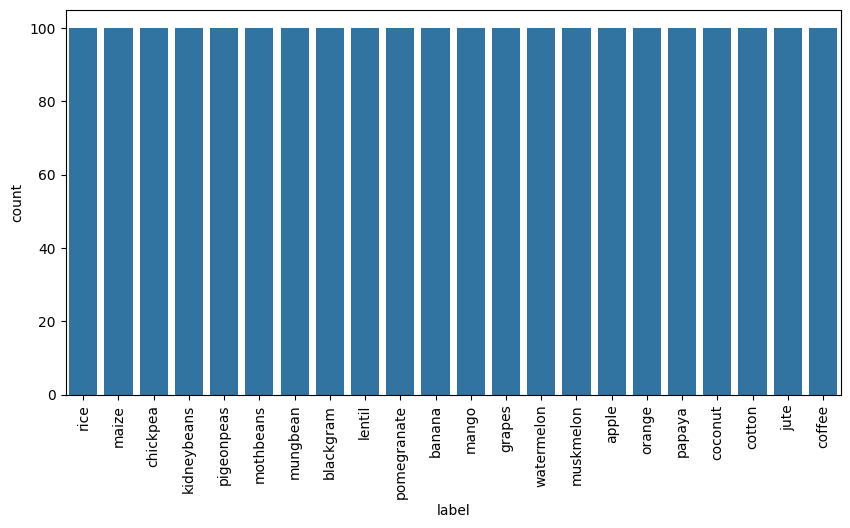

In [14]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))
sns.countplot(x='label', data=df)
plt.xticks(rotation=90)
plt.show()

In [15]:
plt.figure(figsize=(8,6))
sns.heatmap(df.corr(), annot=True)
plt.show()

ValueError: could not convert string to float: 'rice'

<Figure size 800x600 with 0 Axes>

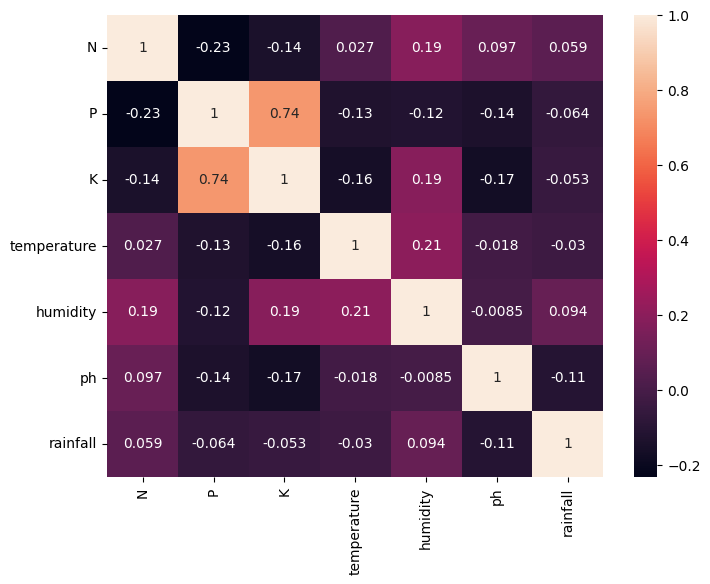

In [16]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,6))
sns.heatmap(df.drop('label', axis=1).corr(), annot=True)
plt.show()

In [17]:
sample = [[90, 40, 40, 25, 80, 6.5, 200]]

prediction = model.predict(sample)
print("Predicted Crop:", prediction[0])

Predicted Crop: jute


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


In [19]:
import pickle

pickle.dump(model, open('crop_model.pkl', 'wb'))

In [20]:
import os
os.listdir()

['.config',
 'drive',
 'Crop_recommendation.csv',
 'crop_model.pkl',
 'sample_data']

In [21]:
os.makedirs('data', exist_ok=True)
os.makedirs('model', exist_ok=True)
os.makedirs('notebooks', exist_ok=True)

In [22]:
import shutil

shutil.move('Crop_recommendation.csv', 'data/Crop_recommendation.csv')
shutil.move('crop_model.pkl', 'model/crop_model.pkl')

'model/crop_model.pkl'

In [23]:
os.listdir('data')
os.listdir('model')

['crop_model.pkl']

In [24]:
from google.colab import files

files.download('model/crop_model.pkl')
files.download('data/Crop_recommendation.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>